In [1]:
import random
import sys

import matplotlib.pyplot as plt
import numpy as np

from collections import defaultdict, Counter
from IPython.display import clear_output

import glob

# sys.path.append("/om2/user/bjmedina/memory/utils/")
# from sequence_utils import *

In [65]:
import random
import numpy as np
from collections import defaultdict, Counter
import matplotlib.pyplot as plt

from IPython.display import clear_output

class ISISequence:
    def __init__(self, length=252, isi_values=[0, 1, 2, 3], seed=15):
        self.length = length
        # sequences with specific guarantees (50% repetition rate, etc), we need to enforce that the length 
        # is divisible by 3
        assert self.length % 3 == 0, "Warning: Sequence length needs to be divisible by 3"
        # ideally, the sequence length should also be a multiple of 3 and the number of positive ISIs
        
        self.isi_values = isi_values
        self.seed = seed
        self.sequences = []
        self.pairs = []
        self._rng = random.Random(seed)
        self._seen_sequences = set()
        self.debug = False

    def toggle_debug(self):
        self.debug = not self.debug

        print(f"Debug switch now turned {self.debug}!")

    def generate_one(self, target_repetition_rate=0.5, min_pairs_per_isi=2):

        from collections import defaultdict

        # functions useful for Step 3: Try to upgrade non-repeats to hit the target repetition rate
        def find_upgradeable_pairs(isi_key, isi_value):
            upgrades = []
            for i in range(len(isi_key) - isi_value - 1):
                j = i + isi_value + 1
                if isi_key[i] == -1 and isi_key[j] == -1:
                    upgrades.append((i, j))
            return upgrades

        def count_nonrepeats(isi_key):
            return sum(1 for x in isi_key if x == -1)

        def count_repeats(isi_key):
            return sum(1 for x in isi_key if x >= 0) // 2

        def current_repetition_rate(num_repeats, num_nonrepeats):
            return num_repeats / (num_repeats + num_nonrepeats) 
        
        good_sequence = False
        desired_num_pairs = self.length // 3 
    
        while not good_sequence:
            
            i = 0

            isi_key = [-2] * self.length
            pairs_by_isi = defaultdict(list)
            pos_isi_values = [isi for isi in self.isi_values if isi >= 0]

            if self.debug:
                print("Before shuffling the ISIs")
                print(pos_isi_values)
            
            self._rng.shuffle(pos_isi_values)

            if self.debug:
                print("After shuffling the ISIs")
                print(pos_isi_values)
            
            isi_index = 0
            repeat_pairs_inserted = 0
    
            # Step 1: Insert as many repeat pairs as possible (with no regards to the desired number of pairs) 
            while i < self.length: #and repeat_pairs_inserted < desired_num_pairs:
                isi = pos_isi_values[isi_index % len(pos_isi_values)]
                isi_index += 1
    
                if i + isi + 1 < self.length and isi_key[i] == -2 and isi_key[i + isi + 1] == -2:
                    isi_key[i] = isi
                    isi_key[i + isi + 1] = isi
                    pairs_by_isi[isi].append((i, i + isi + 1))
                    repeat_pairs_inserted += 1
                    i += 1

                    if self.debug:
                        print(f"inserted isi of {isi} at trial {i} and {i + isi + 1}")
                else:
                    i += 1
                    if self.debug:
                        print(f"inserting isi of {isi} at trial {i} and {i + isi + 1} was not successful")

                #i = i % self.length
    
            # Step 2: Fill remaining slots as non-repeats
            for idx, val in enumerate(isi_key):
                if val == -2:
                    isi_key[idx] = -1
            
            # Step 3: Try to upgrade non-repeats to hit the target repetition rate
            # get the current rep rate
            num_nonrepeats = count_nonrepeats(isi_key)
            num_repeats    = count_repeats(isi_key)
            
            current_rate   = current_repetition_rate(num_repeats, num_nonrepeats)

            while not current_rate == target_repetition_rate:
    
                if current_rate < target_repetition_rate:
    
                    if self.debug:
                       print(f"Current repetition rate {current_rate}")
                    
                    #clear_output(wait=False)
                    #continue
                    self._rng.shuffle(pos_isi_values)
        
                    #while not current_rate == target_repetition_rate:
                    isi = pos_isi_values[isi_index % len(pos_isi_values)]
                    isi_index += 1
                    upgrade_candidates = find_upgradeable_pairs(isi_key, isi)
                    self._rng.shuffle(upgrade_candidates)
                    
                    if len(upgrade_candidates) > 0:
    
                        # Upgrade this pair
                        i1, i2 = upgrade_candidates[-1]
                            
                        isi_key[i1] = isi
                        isi_key[i2] = isi
                        pairs_by_isi[isi].append((i1, i2))
                        repeat_pairs_inserted += 1

                        if self.debug:
                           print(f"Added ({i1}, {i2})")
                        
                        # check the current repetition rate
                        num_nonrepeats = count_nonrepeats(isi_key)
                        num_repeats    = count_repeats(isi_key)
                        current_rate   = current_repetition_rate(num_repeats, num_nonrepeats)
                    
                    if self.debug:
                        print(f" Rep. Rate after additions = {current_rate}")
    
                elif current_rate > target_repetition_rate:
    
                    if self.debug:
                       print(f"Current repetition rate {current_rate}")
                        
                    # GOAL: 
                    # we want to remove pairs until we get to the target reptition rate
                    # particularly the ones that are overrepresented (so if one ISI has a lot of representation in 'pairs_by_isi', i'd like to randomly replace one of those
                    # trials with two non-repeat trials 
                    
                    # Compute how many repeat pairs to remove
                    num_nonrepeats = count_nonrepeats(isi_key)
                    num_repeats = count_repeats(isi_key)
                    excess = num_repeats - int(target_repetition_rate * (num_repeats + num_nonrepeats))
                
                    # Flatten all pairs
                    all_pairs = [(isi, pair) for isi, pairs in pairs_by_isi.items() for pair in pairs]
                    # Sort by overrepresentation
                    all_pairs.sort(key=lambda x: -len(pairs_by_isi[x[0]]))
                    self._rng.shuffle(all_pairs)  # Optional: add noise to avoid bias
                
                    removed = 0
                    for isi, (i1, i2) in all_pairs:
                        if removed >= excess:
                            break
                        if isi_key[i1] == isi and isi_key[i2] == isi:
                            isi_key[i1] = -1
                            isi_key[i2] = -1
                            pairs_by_isi[isi].remove((i1, i2))
                            removed += 1
                            if self.debug:
                               print(f"Removed ({i1}, {i2}).")
                
                    # Recompute rate
                    num_nonrepeats = count_nonrepeats(isi_key)
                    num_repeats = count_repeats(isi_key)
                    current_rate = current_repetition_rate(num_repeats, num_nonrepeats)
                    if self.debug:
                        print(f" Rep. Rate after removals = {current_rate}")


            # Step 3a: Try to add more repeat pairs to underrepresented ISIs
            for isi in pos_isi_values:
                while len(pairs_by_isi[isi]) < min_pairs_per_isi:
                    upgrade_candidates = find_upgradeable_pairs(isi_key, isi)
                    self._rng.shuffle(upgrade_candidates)
                    if not upgrade_candidates:
                        if self.debug:
                            print(f"⚠️ No more upgradeable pairs available for ISI {isi}")
                        break  # can't add more to this ISI
            
                    i1, i2 = upgrade_candidates.pop()
                    isi_key[i1] = isi
                    isi_key[i2] = isi
                    pairs_by_isi[isi].append((i1, i2))
            
                    if self.debug:
                        print(f"✅ Added ({i1}, {i2}) to ISI {isi} (to reach {min_pairs_per_isi})")
            
            # Step 3b: Prune overrepresented ISIs to enforce exact per-ISI balance
            if self.debug:
                for isi in pos_isi_values:
                    print(f"# Pairs for each #IS condition {isi}: {len(pairs_by_isi[isi])}")
                          
            for isi in pos_isi_values:
                while len(pairs_by_isi[isi]) > min_pairs_per_isi:
                    self._rng.shuffle(pairs_by_isi[isi])
                    i1, i2 = pairs_by_isi[isi].pop()
                    isi_key[i1] = -1
                    isi_key[i2] = -1
                    if self.debug:
                        print(f"❌ Pruned ({i1}, {i2}) from #IS {isi} (exceeded {min_pairs_per_isi})")

            for isi in pos_isi_values:
                while len(pairs_by_isi[isi]) < min_pairs_per_isi:
                    upgrade_candidates = find_upgradeable_pairs(isi_key, isi)
                    self._rng.shuffle(upgrade_candidates)
                    if not upgrade_candidates:
                        if self.debug:
                            print(f"⚠️ No more upgradeable pairs available for #IS {isi}")
                        break  # can't add more to this ISI
            
                    i1, i2 = upgrade_candidates.pop()
                    isi_key[i1] = isi
                    isi_key[i2] = isi
                    pairs_by_isi[isi].append((i1, i2))
            
                    if self.debug:
                        print(f"✅ Added ({i1}, {i2}) to ISI {isi} (to reach {min_pairs_per_isi})")

            if self.debug:
                for isi in pos_isi_values:
                    print(f"# Pairs for ISI {isi}: {len(pairs_by_isi[isi])}")
            

            num_nonrepeats = count_nonrepeats(isi_key)
            num_repeats = count_repeats(isi_key)
            current_rate = current_repetition_rate(num_repeats, num_nonrepeats)

            if self.debug:
                print(f"Final repetition rate: {current_rate}")
            
            good_sequence = all(len(pairs_by_isi[isi]) >= min_pairs_per_isi for isi in pos_isi_values)
            if not good_sequence and self.debug:
                print("⚠️ Not all ISIs met the minimum requirement. Regenerating...")
                clear_output(wait=False)

            if not good_sequence:
                clear_output(wait=False)
        
        if self.debug:
            print("CURRENT REPETITION RATE", current_rate)
            print("AFTER:")
            print(isi_key)
            print(pairs_by_isi)
            
        #self.sequences.append(isi_key)
        seq_tuple = tuple(isi_key)
        if seq_tuple not in self._seen_sequences:
            self._seen_sequences.add(seq_tuple)
            self.sequences.append(isi_key)

            for key in pairs_by_isi:
                pairs_by_isi[key] = sorted(pairs_by_isi[key])

            for isi_key_pos, isi in enumerate(isi_key):
                if isi == -1:
                    pairs_by_isi[isi].append(isi_key_pos)

            #pairs_by_isi = sorted(pairs_by_isi)
            pairs_by_isi = {k: pairs_by_isi[k] for k in sorted(pairs_by_isi)}
                    
            self.pairs.append(pairs_by_isi)
        else:
            if self.debug:
                print("⚠️ Duplicate sequence detected. Regenerating...")
                
                
            return self.generate_one(target_repetition_rate, min_pairs_per_isi)
        return isi_key, pairs_by_isi

    def generate_n(self, n, target_repetition_rate=0.5, min_pairs_per_isi=2):
        cumulative_counts = Counter()
    
        for _ in range(n):
            self.seed += 1
            self._rng.seed(self.seed)
    
            isi_key, pairs_by_isi = self.generate_one(
                target_repetition_rate=target_repetition_rate, 
                min_pairs_per_isi=min_pairs_per_isi
            )
    
            #self.sequences.append(isi_key)  # store it
    
            for isi in isi_key:
                if isi >= 0:
                    cumulative_counts[isi] += 1
                else:
                    cumulative_counts[-1] += 1  # track nonrepeats
    
        print("Aggregate ISI usage across all sequences:")
        for isi in sorted(cumulative_counts):
            print(f"  ISI {isi}: {cumulative_counts[isi]}")

    def summary_across(self):
        combined = Counter()
        for isi_key in self.sequences:
            combined.update(Counter(isi_key))
        return dict(combined)

    def get_sequence_and_isi_pairings(self, sequence_id):
        return self.sequences[sequence_id], self.pairs[sequence_id]

    def check_balance(self, verbose=True):
        import numpy as np
    
        summary = self.summary_across()
        pos_isis = [isi for isi in self.isi_values if isi >= 0]
        counts = np.array([summary.get(isi, 0) for isi in pos_isis])
        mean_counts = np.mean(counts)
    
        if verbose:
            print("Total ISI counts across sequences:")
            for isi, count in zip(pos_isis, counts):
                print(f"ISI {isi}: {count}")
    
        mean = np.mean(counts)
        std = np.std(counts)
    
        z_scores = (counts - mean) / std if std > 0 else np.zeros_like(counts)
        max_deviation = np.max(np.abs(z_scores))
    
        if max_deviation > 1:
            print(f"⚠️ ISI imbalance detected (max z-score = {max_deviation:.2f})")
        else:
            print("✅ ISI conditions are statistically balanced (within 1 std deviation).")
        
    def clear_sequences(self):
        """Remove all stored sequences."""
        self.sequences = []

    def plot_summary(self, title="ISI Distribution Across Sequences (n={}, seq. length={})"):
        """Plot a bar chart of ISI usage across all stored sequences."""
        summary = self.summary_across()
    
        # Separate ISI values and counts
        isi_vals = sorted(summary.keys())
        counts = [summary[isi] for isi in isi_vals]
    
        # Plot
        plt.figure(figsize=(8, 5))
        plt.bar([str(isi) for isi in isi_vals], counts, alpha=0.5)
        plt.xlabel("ISI Value")
        plt.ylabel("Number of Trials")
        plt.title(title.format(len(self.sequences), self.length))
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    def plot_avg_isi_across_sequences(self):
        """Plot the average ISI value (excluding -1s) across all stored sequences."""
        import matplotlib.pyplot as plt
        import numpy as np
    
        avg_isis = [
            np.mean([isi for isi in seq if isi >= 0]) if any(isi >= 0 for isi in seq) else 0
            for seq in self.sequences
        ]

        valid_isi_values = [isi for isi in self.isi_values if isi >= 0]
        empirical_avg = np.mean(avg_isis)
        theoretical_avg = np.mean(valid_isi_values)
        
        plt.figure(figsize=(6, 4))
        plt.plot(avg_isis, marker='o', alpha=0.5)
        plt.axhline(y=theoretical_avg, color='red', linestyle='--', label=f'Theoretical Avg = {theoretical_avg:.2f}')
        plt.axhline(y=empirical_avg, color='m', linestyle='--', label=f'Empirical Avg = {empirical_avg:.2f}')        
        plt.xlabel("Sequence Index")
        plt.ylabel("Average ISI (excluding -1)")
        plt.title("Avg. ISI per Sequence")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_avg_position_of_repeats(self):
        """Plot the average position of repeated trials in each sequence."""
        import matplotlib.pyplot as plt
        import numpy as np
    
        avg_positions = [
            np.mean([i for i, isi in enumerate(seq) if isi >= 0]) if any(isi >= 0 for isi in seq) else 0
            for seq in self.sequences
        ]

        theoretical_avg = np.mean(np.arange(self.length))
        empirical_avg = np.mean(avg_positions)

        plt.figure(figsize=(6, 4))
        plt.plot(avg_positions, marker='o', alpha=0.5)
        plt.axhline(y=theoretical_avg, color='red', linestyle='--', label=f'Theoretical Avg = {theoretical_avg:.2f}')
        plt.axhline(y=empirical_avg, color='m', linestyle='--', label=f'Empirical Avg = {empirical_avg:.2f}')

        plt.xlabel("Sequence Index")
        plt.ylabel("Average Position of Repeats")
        plt.title("Avg. Position of Repeat Trials")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_num_repeats_per_sequence(self):
        """Plot the number of repeated stimuli (pairs) per sequence."""
        import matplotlib.pyplot as plt
    
        num_repeats = [sum(isi >= 0 for isi in seq) // 2 for seq in self.sequences]
    
        plt.figure(figsize=(6, 4))
        plt.plot(num_repeats, marker='o')
        plt.xlabel("Sequence Index")
        plt.ylabel("Number of Repeat Stimuli")
        plt.title("Number of Repeats per Sequence")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def plot_isi_position_bias(self, bins=4):
        """
        Visualize ISI distributions across positions in the sequence to detect ISI-specific biases.
        """
        import matplotlib.pyplot as plt
        import numpy as np
        from collections import defaultdict
    
        sequence_length = len(self.sequences[0])
        bin_edges = np.linspace(0, sequence_length, bins + 1, dtype=int)
        isi_labels = sorted({isi for seq in self.sequences for isi in seq if isi >= 0})
    
        counts = {isi: np.zeros(bins) for isi in isi_labels}
    
        for seq in self.sequences:
            for b in range(bins):
                start, end = bin_edges[b], bin_edges[b + 1]
                for i in range(start, end):
                    isi = seq[i]
                    if isi >= 0:
                        counts[isi][b] += 1
    
        # Normalize to get proportions
        totals = np.sum(list(counts.values()), axis=0)
        proportions = {isi: counts[isi] / (totals + 1e-9) for isi in isi_labels}
    
        # Plot
        plt.figure(figsize=(8, 5))
        for isi in isi_labels:
            plt.plot(range(bins), proportions[isi], marker='o', label=f"ISI {isi}")
    
        # Add ideal reference line
        ideal_proportion = 1 / len(isi_labels)
        plt.axhline(ideal_proportion, color='gray', linestyle='--', alpha=0.7, label=f"Ideal = {ideal_proportion:.3f}")
    
        plt.xlabel("Sequence Bin (Position)")
        plt.ylabel("Proportion of ISI Trials")
        plt.title("Distribution of ISI Conditions Across Sequence Positions")
        plt.xticks(range(bins), [f"Bin {i+1}" for i in range(bins)])
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        
    def plot_repetition_rate_per_sequence(self):
        import matplotlib.pyplot as plt
    
        repetition_rates = []
        for seq in self.sequences:
            num_repeats = sum(isi >= 0 for isi in seq) // 2
            num_nonrepeats = sum(isi == -1 for isi in seq)
            total_pairs = num_repeats + num_nonrepeats
            rate = num_repeats / total_pairs
            repetition_rates.append(rate)
    
        plt.figure(figsize=(6, 4))
        plt.plot(repetition_rates, marker='o')
        plt.axhline(0.5, color='red', linestyle='--', label="Target = 0.5")
        plt.xlabel("Sequence Index")
        plt.ylabel("Repetition Rate")
        plt.title("Repetition Rate per Sequence")
        plt.ylim(0, 1)
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_isi_temporal_spread(self, bins=5):
        """
        For each ISI, show how its trials are distributed across sequence positions (bins).
        Y-axis shows, for each ISI, what fraction of its trials fall into each bin.
        """
        import matplotlib.pyplot as plt
        import numpy as np
        from collections import defaultdict
    
        sequence_length = len(self.sequences[0])
        bin_edges = np.linspace(0, sequence_length, bins + 1, dtype=int)
        isi_labels = sorted({isi for seq in self.sequences for isi in seq if isi >= 0})
    
        counts = {isi: np.zeros(bins) for isi in isi_labels}
    
        # Count how many times each ISI appears in each bin
        for seq in self.sequences:
            for b in range(bins):
                start, end = bin_edges[b], bin_edges[b + 1]
                for i in range(start, end):
                    isi = seq[i]
                    if isi >= 0:
                        counts[isi][b] += 1
    
        # Normalize by total count per ISI
        proportions = {}
        for isi in isi_labels:
            total = np.sum(counts[isi])
            if total > 0:
                proportions[isi] = counts[isi] / total
            else:
                proportions[isi] = np.zeros(bins)
    
        # Plot
        plt.figure(figsize=(8, 5))
        for isi in isi_labels:
            plt.plot(range(bins), proportions[isi], marker='o', label=f"ISI {isi}")
    
        plt.xlabel("Sequence Bin (Position)")
        plt.ylabel("Proportion of ISI Occurrences")
        plt.title("Temporal Spread of Each ISI Across Sequence Bins")
        plt.xticks(range(bins), [f"Bin {i+1}" for i in range(bins)])
        plt.axhline(1/bins, color='gray', linestyle='--', alpha=0.5, label="Ideal = uniform")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def check_for_duplicate_sequences(self):
        from collections import Counter
    
        seq_tuples = [tuple(seq) for seq in self.sequences]
        counts = Counter(seq_tuples)
        duplicates = {k: v for k, v in counts.items() if v > 1}
    
        if duplicates:
            print("⚠️ Duplicate sequences found:")
            for seq, count in duplicates.items():
                print(f"  Occurs {count} times")
        else:
            print("✅ No duplicate sequences.")

def getAnswerKey(seq):
    """
    Returns a list where each position is:
    - 0 if the stimulus has not been seen before
    - 1 if the stimulus has already occurred earlier in the sequence
    """
    seen = set()
    answer_key = []

    for stim in seq:
        if stim in seen:
            answer_key.append(1)
        else:
            answer_key.append(0)
            seen.add(stim)

    return answer_key

class StimulusManager:
    def __init__(self, stimulus_ids, isi_values, length=258, seed=5):
        self._rng = random.Random(seed)
        self.stimulus_ids = list(stimulus_ids)
        self._rng.shuffle(self.stimulus_ids)
        self.n = length
        self.isi_values = sorted(isi_values)
        self.seq_index = 0
        self.assignment_log = []
        self.debug = False
        self.stimulus_rotation_step = self.n // (3 * (len(self.isi_values) - 1))  # exclude -1
        self.stimulus_offset = 0
        self.assignments = []
        self.seqs = []
        self.seed = seed

    def toggle_debug(self):
        self.debug = not self.debug
        print(f"Debug switch now turned {self.debug}!")

    def get_assignments_from_pairs(self, pairs_by_isi, seq=None):
        """
        Assign stimuli deterministically to ISI conditions using rotation and pair counts.
        """
        assignments = [-1] * self.n
        assignment_log = {}

        # Roll stimulus list by offset based on sequence number
        rolled = np.roll(self.stimulus_ids, -self.stimulus_offset)#np.roll(self.stimulus_ids, -sum(len(log) for log in self.assignment_log))
        pointer = 0
        self.stimulus_offset = (self.stimulus_offset + self.stimulus_rotation_step) % len(self.stimulus_ids)
        
        # Track which indices are already assigned
        for isi in sorted(pairs_by_isi):
            
            entries = pairs_by_isi[isi]
            
            if self.debug:
                print(isi, entries)
                print("\n")
            
            for item in entries:
                stim = rolled[pointer]
                pointer += 1

                if isinstance(item, tuple):  # Repeat trial (i1, i2)
                    i1, i2 = item
                    assignments[i1] = stim
                    assignments[i2] = stim
                    assignment_log[stim] = {'isi': isi, 'type': 'repeat', 'pos': i2}
                else:  # Non-repeat trial (just one index)
                    i = item
                    assignments[i] = stim
                    assignment_log[stim] = {'isi': isi, 'type': 'nonrepeat'}
                
        if any(a == -1 for a in assignments):
            raise RuntimeError("Unassigned positions remain.")

        assignment_log = dict(sorted(assignment_log.items()))

        self.assignment_log.append(assignment_log)
        self.assignments.append(assignments)
        self.seqs.append(seq)
        self.seq_index += 1
        return assignments
    
    def save_current_assignments(self, isi_key, repetition_rate, getAnswerKey=None):
        """
        Save the current assignment info from the last sequence generation.
        - seq: The output of get_assignments_from_pairs()
        - isi_key: List of ISIs for each position (len = self.n)
        - repetition_rate: Float indicating how many repeats per total
        - getAnswerKey: Optional function to get answer key from sequence
        """
    
        last_log = self.assignment_log[-1]
    
        # Map stimulus index to filename
        stim_id_to_filename = {i: stim for i, stim in enumerate(self.stimulus_ids)}
    
        # Reconstruct filenames for current sequence
        seq_filenames = [stim_id_to_filename[s] if s in stim_id_to_filename else None for s in seq]
    
        # YouTube IDs, assuming filenames contain them
        yt_ids = [f.split("_")[-1].replace(".wav", "") if f else None for f in seq_filenames]
    
        data = {
            "repetition_rate": repetition_rate,
            "order": seq,
            "filenames_order": seq_filenames,
            "yt_id": yt_ids,
            "isi": isi_key,
            "key": getAnswerKey(seq) if getAnswerKey else None,
        }
    
        return data

    def save_sequence_to_json(self, assignments, seq, index, tol, kind, base_path, prefix="exemplar"):
        filenames_order = assignments
        isi = seq
        key = self._compute_answer_key(filenames_order)

        isi_counts = dict(Counter(isi))
        isi_counts_str_keys = {str(k): v for k, v in isi_counts.items()}


        def count_nonrepeats(isi_key):
            return sum(1 for x in isi_key if x == -1)

        def count_repeats(isi_key):
            return sum(1 for x in isi_key if x >= 0) // 2

        def current_repetition_rate(num_repeats, num_nonrepeats):
            return num_repeats / (num_repeats + num_nonrepeats) 

        
        repetition_rate = current_repetition_rate(count_repeats(isi), count_nonrepeats(isi))

        data = {
            **isi_counts_str_keys,
            "repetition_rate": repetition_rate,
            "order": [int(re.search(r"mem_stim_num(\d+).wav", s).group(1)) for s in filenames_order],
            "filenames_order": [f.split("/")[-1] for f in filenames_order],
            "isi": isi,
            "key": key
        }
        
        out_path = self._generate_filename(index=index, length=self.n, tol=tol, seed=self.seed, kind=kind, base_path=base_path, prefix=prefix)

        with open(out_path, "w") as f:
            json.dump(data, f, indent=2)

        print(f"Saved {kind} sequence to: {out_path}")
        return out_path

    def _generate_filename(self, index, length, tol, seed, kind, base_path, prefix=""):
        isi_str = self._isi_string()
        fname = f"{prefix}seq{index:03}_len{length}_tol{tol}_s{seed}_{isi_str}.json"
        return os.path.join(base_path, fname)

    def _compute_answer_key(self, filenames_order):
        seen = set()
        key = []
        for stim in filenames_order:
            if stim in seen:
                key.append(1)
            else:
                key.append(0)
                seen.add(stim)
        return key

    def _isi_string(self):
        isi_str = "isi" + "_".join(f"{isi:.1f}".replace(".", "p") for isi in sorted(self.isi_values))
        return isi_str


    def check_isi_rotation(self):
        if len(self.assignment_log) < 2:
            print("Not enough sequences to check rotation.")
            return
    
        isi_order = sorted(self.isi_values)
        prev_log = self.assignment_log[-2]
        curr_log = self.assignment_log[-1]
        errors = []
    
        for stim, prev_info in prev_log.items():
            if stim in curr_log:
                curr_info = curr_log[stim]
                # Only check if both are repeat trials
                if prev_info['type'] == 'repeat' and curr_info['type'] == 'repeat':
                    prev_isi = prev_info['isi']
                    curr_isi = curr_info['isi']
    
                    # What ISI should come next in the cycle?
                    prev_index = isi_order.index(prev_isi)
                    expected_next_isi = isi_order[(prev_index + 1) % len(isi_order)]
    
                    if curr_isi != expected_next_isi:
                        errors.append((stim, prev_isi, curr_isi, expected_next_isi))
    
        if not errors:
            print("✅ All repeat stimuli rotated ISI correctly.")
        else:
            print("⚠️ ISI rotation mismatch found:")
            for stim, prev, curr, expected in errors:
                print(f"  Stim {stim}: was ISI {prev}, now ISI {curr}, expected ISI {expected}")

    def plot_stimulus_isi_history(self, max_stimuli=10):
        """
        Plot how ISI assignments changed over time for selected stimuli.
        Shows if ISI assignments cycle across sequences.
    
        Args:
            max_stimuli (int): Number of stimuli to visualize.
        """
        stim_to_isi_history = defaultdict(list)
    
        # Gather ISI history for each stimulus across sequences
        for seq_idx, log in enumerate(self.assignment_log):
            for stim, entry in sorted(log.items()):
                stim_to_isi_history[stim].append((seq_idx, entry['isi']))
    
        # Select up to max_stimuli for plotting
        selected_stims = list(stim_to_isi_history.keys())[:max_stimuli]
    
        # Plot
        plt.figure(figsize=(10, 5))
        for stim in selected_stims:
            points = stim_to_isi_history[stim]
            x = [seq for seq, _ in points]
            y = [isi for _, isi in points]
            plt.plot(x, y, marker='o', label=f"Stim {stim}", alpha=0.25)
    
        plt.xlabel("Sequence Index")
        plt.ylabel("Assigned ISI")
        plt.title("ISI Assignment History per Stimulus")
        plt.yticks(sorted(self.isi_values))
        plt.xticks(range(len(self.assignment_log)), rotation=-50)  # Force integer ticks
        plt.grid(True, linestyle='--', alpha=0.5)
        
        if max_stimuli <= 10:
            plt.legend(title="Stimulus ID", bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

    def check_unique_stimuli_per_isi(self, plot=True):
        """
        Count how many unique stimuli were assigned to each ISI across all sequences.
        
        Args:
            plot (bool): Whether to show a bar plot of results.
        
        Returns:
            dict: ISI → number of unique stimuli
        """
        isi_to_stims = defaultdict(set)

        for seq_log in self.assignment_log:
            for stim, info in seq_log.items():
                isi = info['isi']
                isi_to_stims[isi].add(stim)

        isi_counts = {isi: len(stims) for isi, stims in isi_to_stims.items()}

        if plot:
            plt.figure(figsize=(6, 4))
            plt.bar([str(isi) for isi in sorted(isi_counts)], 
                    [isi_counts[isi] for isi in sorted(isi_counts)])
            plt.xlabel("ISI Value")
            plt.ylabel("Number of Unique Stimuli Assigned")
            plt.title("Unique Stimuli per ISI Across All Sequences")
            plt.grid(axis='y', linestyle='--', alpha=0.6)
            plt.tight_layout()
            plt.show()

        return isi_counts

    def plot_stimulus_isi_usage(self, max_stimuli=50):
        """
        Plot how many times each stimulus has been assigned to each *non-repeat* ISI.
        
        Args:
            max_stimuli (int): Max number of stimuli to display in the heatmap.
        """
        import pandas as pd
        import seaborn as sns
        import matplotlib.pyplot as plt
        from collections import defaultdict
    
        stim_isi_counts = defaultdict(lambda: defaultdict(int))
    
        # Count stimulus usage by ISI (excluding -1)
        for log in self.assignment_log:
            for stim, entry in log.items():
                isi = entry['isi']
                if isi == -1:
                    continue
                stim_isi_counts[stim][isi] += 1
    
        # Create DataFrame
        df = pd.DataFrame(stim_isi_counts).fillna(0).astype(int).T
        df = df.sort_index().iloc[:max_stimuli]  # limit rows
    
        # Sort ISI columns numerically
        df = df[sorted(df.columns)]
    
        # Plot
        plt.figure(figsize=(10, 6))
        sns.heatmap(df, annot=True, fmt='d', cmap="YlGnBu", 
                    cbar_kws={'label': 'Usage Count'}, xticklabels=True, yticklabels=True)
        plt.xlabel("ISI (excluding -1)")
        plt.ylabel("Stimulus")
        plt.title("Stimulus × ISI Usage Frequency")
        plt.xticks(rotation=0)
        #plt.yticks(rotation=0)
        plt.yticks([], [])
        plt.tight_layout()
        plt.show()

    def check_stimulus_position_distribution(self, plot=True):
        """
        Analyze the average position of each stimulus across all sequences.
        
        Args:
            plot (bool): Whether to display the position histogram.
        
        Returns:
            dict: stimulus → list of trial indices it appeared in
        """
        from collections import defaultdict
        import numpy as np
        import matplotlib.pyplot as plt
    
        stim_positions = defaultdict(list)
    
        # Reconstruct positions from assignment logs
        for seq_idx, log in enumerate(self.assignment_log):
            for i in range(self.n):  # positions in the sequence
                for stim, entry in log.items():
                    if entry['type'] == 'repeat':
                    #if entry.get('index') == i:  # optional if you've stored index
                        stim_positions[stim].append(entry['pos'])
    
        # Or, if you're reconstructing from assignments directly:
        # for seq_idx, assignments in enumerate(self.assignments):  # if stored
        #     for i, stim in enumerate(assignments):
        #         stim_positions[stim].append(i)
    
        # Compute average position for each stimulus
        stim_avg_position = {stim: np.mean(positions) for stim, positions in stim_positions.items()}
    
        if plot:
            plt.figure(figsize=(6, 4))
            plt.hist(stim_avg_position.values(), bins=self.n, color='orange', edgecolor='black')
            plt.axvline(self.n / 2, color='red', linestyle='--', label='Sequence Midpoint')
            plt.xlabel("Average Sequence Position")
            plt.ylabel("Number of Stimuli")
            plt.title("Stimulus Position Distribution Across Sequences")
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.6)
            plt.tight_layout()
            plt.show()
    
        return stim_avg_position


class StimulusManagerTextureVsExemplar(StimulusManager):
    def __init__(self, n_stimuli, isi_values, length=258, seed=5, base_path=""):
        """
        Initialize with a number of base stimuli (assumes both _1.wav and _2.wav exist for each).
        """
        super().__init__([], isi_values, length=length, seed=seed)
        self.base_path = base_path.rstrip("/")
        self.base_ids = list(range(n_stimuli))
        self.n_stimuli = n_stimuli
        self._rng.shuffle(self.base_ids)  # Shuffle base indices

        self.stimulus_rotation_step = length // (3 * (len(isi_values) - 1))  # exclude -1
        self.stimulus_offset = 0

        # Create full stimulus paths
        self.stimulus_ids = [
            f"{self.base_path}/mem_stim_num{i+1}_{j}.wav"
            for i in self.base_ids
            for j in [1, 2]
        ]
        self.available_pairs = [(f"{self.base_path}/mem_stim_num{i+1}_1.wav",
                                 f"{self.base_path}/mem_stim_num{i+1}_2.wav") for i in self.base_ids]

        self.seed = seed

    def get_assignments_from_pairs(self, pairs_by_isi, seq=None):
        """
        Assign repeat trials as either exemplar or texture. Balanced per ISI.
        """
        assignments = [-1] * self.n
        assignment_log = {}
        pointer = 0

        for isi in sorted(pairs_by_isi):
            entries = pairs_by_isi[isi]
            repeat_entries = [item for item in entries if isinstance(item, tuple)]
            nonrepeat_entries = [item for item in entries if not isinstance(item, tuple)]

            if len(repeat_entries) % 2 != 0:
                raise ValueError(f"ISI {isi} must have even repeat count.")

            half = len(repeat_entries) // 2

            # Non-repeat assignments
            for i in nonrepeat_entries:
                stim = self.available_pairs[pointer][0]
                pointer += 1
                assignments[i] = stim
                assignment_log[stim] = {'isi': isi, 'type': 'nonrepeat'}

            # Repeat assignments
            for j, (i1, i2) in enumerate(repeat_entries):
                stim_1, stim_2 = self.available_pairs[pointer]
                pointer += 1

                if j < half:
                    # EXEMPLAR: same file twice
                    assignments[i1] = stim_1
                    assignments[i2] = stim_1
                    assignment_log[stim_1] = {'isi': isi, 'type': 'repeat_exemplar', 'pos': (i1, i2)}
                else:
                    # TEXTURE: _1.wav followed by _2.wav
                    assignments[i1] = stim_1
                    assignments[i2] = stim_2
                    assignment_log[f"{stim_1},{stim_2}"] = {
                        'isi': isi, 'type': 'repeat_texture', 'pos': (i1, i2)
                    }

        if any(a == -1 for a in assignments):
            raise RuntimeError("Unassigned positions remain.")

        self.assignment_log.append(dict(sorted(assignment_log.items())))
        self.assignments.append(assignments)
        self.seqs.append(seq)
        self.seq_index += 1
        return assignments

    def get_dual_assignments_from_pairs(self, pairs_by_isi, seq=None):
        """
        Generate two assignments per ISI: one where half of the repeat trials are exemplar
        and half are texture, and another where the roles are swapped.
        """
        assignments_1 = [-1] * self.n
        assignments_2 = [-1] * self.n
        log_1 = {}
        log_2 = {}
        
        rotated_pairs = np.roll(self.available_pairs, -(self.stimulus_offset*2))#np.roll(self.stimulus_ids, -sum(len(log) for log in self.assignment_log))
        pointer = 0
        self.stimulus_offset = (self.stimulus_offset + self.stimulus_rotation_step) % self.n_stimuli
    
        for isi in sorted(pairs_by_isi):
            entries = pairs_by_isi[isi]
            repeat_entries = [item for item in entries if isinstance(item, tuple)]
            nonrepeat_entries = [item for item in entries if not isinstance(item, tuple)]

            self._rng.shuffle(nonrepeat_entries)
            self._rng.shuffle(repeat_entries)
            if len(repeat_entries) % 2 != 0:
                raise ValueError(f"ISI {isi} must have even repeat count.")
    
            # --- Non-repeats (same for both) ---
            for i in nonrepeat_entries:
                stim = rotated_pairs[pointer][0]
                stim_id = int(stim.split("/")[-1].split("_")[-2][3:])
                pointer += 1
                assignments_1[i] = stim
                assignments_2[i] = stim
                log_1[stim_id] = {'isi': isi, 'type': 'nonrepeat'}
                log_2[stim_id] = {'isi': isi, 'type': 'nonrepeat'}
    
            # --- Repeats in pairs of two ---
            for i in range(0, len(repeat_entries), 2):
                (i1a, i2a) = repeat_entries[i]
                (i1b, i2b) = repeat_entries[i + 1]

                stimA_1, stimA_2 = rotated_pairs[pointer]
                stimB_1, stimB_2 = rotated_pairs[pointer + 1]

                stimA_1_id = int(stimA_1.split("/")[-1].split("_")[-2][3:])
                stimB_1_id = int(stimB_1.split("/")[-1].split("_")[-2][3:])  
                #print(stimA_1_id, stimB_1_id)
                
                pointer += 2
    
                # Assignment 1: A is exemplar, B is texture
                assignments_1[i1a] = stimA_1
                assignments_1[i2a] = stimA_1
                log_1[stimA_1_id] = {'isi': isi, 'type': 'repeat_exemplar', 'pos': (i1a, i2a)}
    
                assignments_1[i1b] = stimB_1
                assignments_1[i2b] = stimB_2
                log_1[stimB_1_id] = {'isi': isi, 'type': 'repeat_texture', 'pos': (i1b, i2b)}
    
                # Assignment 2: A is texture, B is exemplar
                assignments_2[i1a] = stimA_1
                assignments_2[i2a] = stimA_2
                log_2[stimA_1_id] = {'isi': isi, 'type': 'repeat_texture', 'pos': (i1a, i2a)}
    
                assignments_2[i1b] = stimB_1
                assignments_2[i2b] = stimB_1
                log_2[stimB_1_id] = {'isi': isi, 'type': 'repeat_exemplar', 'pos': (i1b, i2b)}
    
        # Safety check
        if any(a == -1 for a in assignments_1 + assignments_2):
            raise RuntimeError("Unassigned positions remain in one of the sequences.")
    
        self.assignment_log.append(dict(sorted(log_1.items())))
        self.assignment_log.append(dict(sorted(log_2.items())))
        self.assignments.append(assignments_1)
        self.assignments.append(assignments_2)
        self.seqs.append(seq)
        self.seqs.append(seq)
        self.seq_index += 2
    
        return assignments_1, assignments_2

    def save_sequence_to_json(self, assignments, seq, index, tol, kind, base_path, prefix="texture_vs_exemplar"):
        filenames_order = assignments
        isi = seq
        key = self._compute_answer_key(filenames_order)

        isi_counts = dict(Counter(isi))
        isi_counts_str_keys = {str(k): v for k, v in isi_counts.items()}


        def count_nonrepeats(isi_key):
            return sum(1 for x in isi_key if x == -1)

        def count_repeats(isi_key):
            return sum(1 for x in isi_key if x >= 0) // 2

        def current_repetition_rate(num_repeats, num_nonrepeats):
            return num_repeats / (num_repeats + num_nonrepeats) 

        
        repetition_rate = current_repetition_rate(count_repeats(isi), count_nonrepeats(isi))

        data = {
            **isi_counts_str_keys,
            "repetition_rate": repetition_rate,
            "order": [int(re.search(r"mem_stim_num(\d+)_", s).group(1)) for s in filenames_order],
            "filenames_order": [f.split("/")[-1] for f in filenames_order],
            "isi": isi,
            "key": key
        }
        
        out_path = self._generate_filename(index=index, length=self.n, tol=tol, seed=self.seed, kind=kind, base_path=base_path, prefix=prefix)

        with open(out_path, "w") as f:
            json.dump(data, f, indent=2)

        print(f"Saved {kind} sequence to: {out_path}")
        return out_path

    def _generate_filename(self, index, length, tol, seed, kind, base_path, prefix=""):
        isi_str = self._isi_string()
        fname = f"{prefix}seq{index:03}_len{length}_tol{tol}_s{seed}_{isi_str}.json"
        return os.path.join(base_path, fname)

    def _compute_answer_key(self, filenames_order):
        seen = set()
        key = []
        for stim in filenames_order:
            if stim in seen:
                key.append(1)
            else:
                key.append(0)
                seen.add(stim)
        return key

    def _isi_string(self):
        isi_str = "isi" + "_".join(f"{isi:.1f}".replace(".", "p") for isi in sorted(self.isi_values))
        return isi_str

    def plot_stimulus_occurrences(self):
        """
        Bar‐plot of total counts across all sequences for each stimulus ID:
          • as exemplar repeats
          • as texture repeats
        """
        # tally counters
        counts_ex = defaultdict(int)
        counts_tx = defaultdict(int)

        for log in self.assignment_log:
            for stim_key, info in log.items():
                t = info.get('type','')
                if t == 'repeat_exemplar':
                    # stim_key is a single path
                    #m = re.search(r'mem_stim_num(\d+)', stim_key)
                    #if m:
                    counts_ex[stim_key] += 1
                elif t == 'repeat_texture':
                    # stim_key is "path1,path2"
                    #for part in stim_key.split(','):
                        #m = re.search(r'mem_stim_num(\d+)', part)
                        #if m:
                    counts_tx[stim_key] += 1

        # all stimulus IDs that appeared
        all_ids = sorted(set(counts_ex) | set(counts_tx))
        ex_vals = [counts_ex[i] for i in all_ids]
        tx_vals = [counts_tx[i] for i in all_ids]

        # plot
        x = np.arange(len(all_ids))
        width = 0.35

        fig, ax = plt.subplots(figsize=(12,6))
        ax.bar(x - width/2, ex_vals, width, label='Exemplar', alpha=0.7)
        ax.bar(x + width/2, tx_vals, width, label='Texture',  alpha=0.7)

        ax.set_xticks(x)
        ax.set_xticklabels(all_ids, rotation='vertical')
        ax.set_xlabel("Stimulus ID")
        ax.set_ylabel("Total Occurrences")
        ax.set_title("Stimulus Occurrence as Exemplar vs Texture Repeats")
        ax.legend()
        plt.tight_layout()
        plt.show()

    def plot_average_repeat_positions(self):
        """
        Plot the average sequence position of each stimulus when repeated,
        separately for exemplar vs. texture repeats.
        """
        pos_ex = defaultdict(list)
        pos_tx = defaultdict(list)

        for log in self.assignment_log:
            for stim_id, info in log.items():
                typ = info.get('type')
                if typ not in ('repeat_exemplar', 'repeat_texture'):
                    continue
                i1, i2 = info['pos']
                mean_pos = (i1 + i2) / 2.0
                if typ == 'repeat_exemplar':
                    pos_ex[stim_id].append(mean_pos)
                else:
                    pos_tx[stim_id].append(mean_pos)

        all_ids = sorted(set(pos_ex) | set(pos_tx))
        ex_means = [np.mean(pos_ex[i]) if pos_ex[i] else np.nan for i in all_ids]
        tx_means = [np.mean(pos_tx[i]) if pos_tx[i] else np.nan for i in all_ids]

        x = np.arange(len(all_ids))
        width = 0.35

        fig, ax = plt.subplots(figsize=(12, 6))
        ax.bar(x - width/2, ex_means, width, label='Exemplar', alpha=0.7)
        ax.bar(x + width/2, tx_means, width, label='Texture', alpha=0.7)
        ax.set_xticks(x)
        ax.set_xticklabels(all_ids, rotation='vertical')
        ax.set_xlabel("Stimulus ID")
        ax.set_ylabel("Average Position in Sequence")
        ax.set_title("Average Repeat Position: Exemplar vs. Texture")
        ax.legend()
        plt.tight_layout()
        plt.show()


    def plot_average_isi(self):
        """
        Plot the average ISI (interstimulus interval) for each stimulus when repeated,
        separately for exemplar vs. texture repeats.
        """
        isi_ex = defaultdict(list)
        isi_tx = defaultdict(list)

        for log in self.assignment_log:
            for stim_id, info in log.items():
                typ = info.get('type')
                isi = info.get('isi')
                if isi is None or typ not in ('repeat_exemplar', 'repeat_texture'):
                    continue
                if typ == 'repeat_exemplar':
                    isi_ex[stim_id].append(isi)
                else:
                    isi_tx[stim_id].append(isi)

        all_ids = sorted(set(isi_ex) | set(isi_tx))
        ex_means = [np.mean(isi_ex[i]) if isi_ex[i] else np.nan for i in all_ids]
        tx_means = [np.mean(isi_tx[i]) if isi_tx[i] else np.nan for i in all_ids]

        x = np.arange(len(all_ids))
        width = 0.35

        fig, ax = plt.subplots(figsize=(12, 6))
        ax.bar(x - width/2, ex_means, width, label='Exemplar ISI', alpha=0.7)
        ax.bar(x + width/2, tx_means, width, label='Texture ISI', alpha=0.7)
        ax.set_xticks(x)
        ax.set_xticklabels(all_ids, rotation='vertical')
        ax.set_xlabel("Stimulus ID")
        ax.set_ylabel("Average ISI (trials between repeats)")
        ax.set_title("Average Inter-Stimulus Interval: Exemplar vs. Texture")
        ax.legend()
        plt.tight_layout()
        plt.show()
        
def save_all_sequences(manager, tol, base_path, prefix="texture_vs_exemplar"):
    """
    Save all assignment/sequence pairs stored in the manager using its own save_sequence_to_json method.
    
    Args:
        manager: StimulusManagerTextureVsExemplar instance
        tol: The tolerance used when creating the sequence (used for filename)
        base_path: Directory to save JSON files
        prefix: Optional prefix for filenames
    """
    os.makedirs(base_path, exist_ok=True)

    for i, (assignments, seq) in enumerate(zip(manager.assignments, manager.seqs)):
        kind = "exemplar_first" if i % 2 == 0 else "texture_first"
        manager.save_sequence_to_json(
            assignments=assignments,
            seq=seq,
            index=i+1,
            tol=tol,
            kind=kind,
            base_path=base_path,
            prefix=prefix
        )


def print_pairs_by_isi(pairs_by_isi):
    print("ISI Pairings Summary:\n")
    for isi in sorted(pairs_by_isi):
        values = pairs_by_isi[isi]
        count = len(values)
        print(f"ISI {isi}: {count} item(s)")
        print(f"  {values}\n")

In [66]:
len_exp = 216 # needs to be a multiple of 3 (2 non-repeat, 1 repeat trials -> three trials)

unique_stim_needed = int((len_exp/3)*2)
ISI_conditions = [-1, 0, 16] 

total_pairs_of_repeat_stimuli = int(len_exp / 3) 
min_pairs_per_isi = int(total_pairs_of_repeat_stimuli / (len(ISI_conditions) - 1)) #len(ISI_conditions) - 1 because we don't count the -1 isi condition (nonrepeats)

manager = ISISequence(length=len_exp, 
                      isi_values=ISI_conditions, 
                      seed=14)

n_gen_seqs = 150
manager.generate_n(n=n_gen_seqs, 
                   min_pairs_per_isi=min_pairs_per_isi)


#manager.toggle_debug()

Aggregate ISI usage across all sequences:
  ISI -1: 10800
  ISI 0: 10800
  ISI 16: 10800


In [67]:
# len_exp = 120 # needs to be a multiple of 3 (2 non-repeat, 1 repeat trials -> three trials)

# unique_stim_needed = int((len_exp/3)*2)
# ISI_conditions = [-1, 0, 1, 2, 4, 8] 

# total_pairs_of_repeat_stimuli = int(len_exp / 3) 
# min_pairs_per_isi = int(total_pairs_of_repeat_stimuli / (len(ISI_conditions) - 1)) #len(ISI_conditions) - 1 because we don't count the -1 isi condition (nonrepeats)

# manager = ISISequence(length=len_exp, 
#                       isi_values=ISI_conditions, 
#                       seed=14)


# #manager.toggle_debug()

In [68]:
n_gen_seqs = 120
manager.generate_n(n=n_gen_seqs, 
                   min_pairs_per_isi=min_pairs_per_isi) #generates n many sequnces
#print(len(manager.sequences))

Aggregate ISI usage across all sequences:
  ISI -1: 8640
  ISI 0: 8640
  ISI 16: 8640


In [69]:
manager.check_balance()

Total ISI counts across sequences:
ISI 0: 19440
ISI 16: 19440
✅ ISI conditions are statistically balanced (within 1 std deviation).


In [70]:
import re
import glob

# def extract_index(path):
#     # Extract the first number that appears after "mem_stim_num"
#     match = re.search(r'mem_stim_num(\d+)_', path)
#     return int(match.group(1)) if match else float('inf')  # fallback just in case


pairs_path = "/mindhive/mcdermott/www/mturk_stimuli/bjmedina/texture_from_disc_pairs"
all_sound_pairs = sorted(glob.glob(pairs_path + "/*num*.wav"))
all_sounds = sorted(glob.glob(pairs_path + "/*num*.wav"))
#print(*all_sounds, sep="\n")
#print(total_pairs_of_repeat_stimuli, len(all_sounds))

In [71]:
all_sound_pairs = sorted(all_sound_pairs, key=extract_index)
#print(*all_sound_pairs, sep="\n")
#print(*all_sound_pairs, sep="\n")

all_sounds = sorted(all_sounds)
#print(*all_sounds, sep="\n")

In [72]:
unique_stim_needed

144

In [73]:
sm = StimulusManager(stimulus_ids=all_sounds,#np.arange(total_pairs_of_repeat_stimuli*2, dtype=np.int32),
                     isi_values=ISI_conditions, 
                     length=len_exp, 
                     seed=12)

for j in range(n_gen_seqs):

    seq, pairs = manager.get_sequence_and_isi_pairings(j)

    sm.get_assignments_from_pairs(pairs, seq=seq)

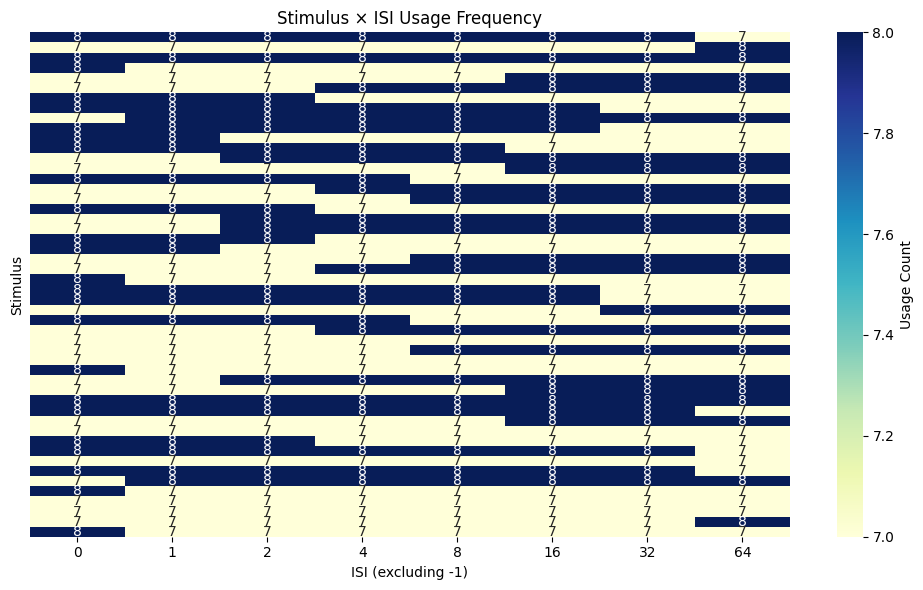

In [61]:
sm.plot_stimulus_isi_usage()


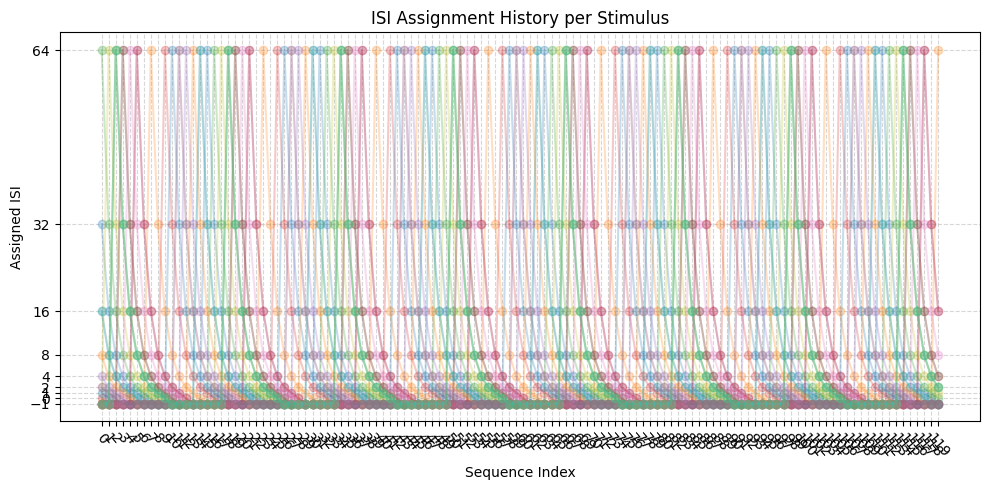

In [62]:
sm.plot_stimulus_isi_history(max_stimuli=20)


In [63]:
import os
import json
import stat
save_all_sequences(sm, 0, base_path=f"/mindhive/mcdermott/www/mturk_stimuli/bjmedina/texture_from_disc_pairs/sequences/max_isi_{max(ISI_conditions)}_v2/len{len_exp}", prefix="")

seqs_path = f"/mindhive/mcdermott/www/mturk_stimuli/bjmedina/texture_from_disc_pairs/sequences/max_isi_{max(ISI_conditions)}_v2/len{len_exp}"
mindhive_results_path = f"/mindhive/mcdermott/www/bjmedina/experiments/textures/results/max_isi_{max(ISI_conditions)}_v2/len{len_exp}"

def initialize_sequence_tracking(sequence_dir, extension=".json"):
    """
    Initialize tracking files for unused and used sequences.

    Creates:
      - sequence_dir/unused/unused.json
      - sequence_dir/used/used.json

    Args:
        sequence_dir (str): Base directory where sequence JSONs and subdirs live
        extension (str): File extension to track (default: '.json')
    """
    unused_dir = os.path.join(sequence_dir, "unused")
    used_dir = os.path.join(sequence_dir, "used")

    os.makedirs(unused_dir, exist_ok=True)
    os.makedirs(used_dir, exist_ok=True)

    # List all JSON sequence files in the base directory (not inside used/ or unused/)
    all_sequences = sorted([
        f for f in os.listdir(sequence_dir)
        if f.endswith(extension) and os.path.isfile(os.path.join(sequence_dir, f))
    ])

    # Save to unused/unused.json
    unused_path = os.path.join(unused_dir, "unused.json")
    with open(unused_path, "w") as f:
        json.dump(all_sequences, f, indent=2)
    print(f"✅ Created unused.json with {len(all_sequences)} sequences.")

    # Save to used/used.json (empty)
    used_path = os.path.join(used_dir, "used.json")
    with open(used_path, "w") as f:
        json.dump([], f, indent=2)
    print(f"✅ Created used.json (empty).")

initialize_sequence_tracking(seqs_path)

def create_and_chmod_dirs(full_path):
    # Create directories if they don't exist
    os.makedirs(full_path, exist_ok=False)

    # Get the final two directories in the path
    full_path = os.path.abspath(full_path)
    final2 = full_path
    final1 = os.path.dirname(final2)

    # Apply chmod 777 (read/write/execute for everyone)
    os.chmod(final1, stat.S_IRWXU | stat.S_IRWXG | stat.S_IRWXO)
    os.chmod(final2, stat.S_IRWXU | stat.S_IRWXG | stat.S_IRWXO)

# Example usage
create_and_chmod_dirs(mindhive_results_path)

Saved exemplar_first sequence to: /mindhive/mcdermott/www/mturk_stimuli/bjmedina/texture_from_disc_pairs/sequences/max_isi_64_v2/len216/seq001_len216_tol0_s12_isi-1p0_0p0_1p0_2p0_4p0_8p0_16p0_32p0_64p0.json
Saved texture_first sequence to: /mindhive/mcdermott/www/mturk_stimuli/bjmedina/texture_from_disc_pairs/sequences/max_isi_64_v2/len216/seq002_len216_tol0_s12_isi-1p0_0p0_1p0_2p0_4p0_8p0_16p0_32p0_64p0.json
Saved exemplar_first sequence to: /mindhive/mcdermott/www/mturk_stimuli/bjmedina/texture_from_disc_pairs/sequences/max_isi_64_v2/len216/seq003_len216_tol0_s12_isi-1p0_0p0_1p0_2p0_4p0_8p0_16p0_32p0_64p0.json
Saved texture_first sequence to: /mindhive/mcdermott/www/mturk_stimuli/bjmedina/texture_from_disc_pairs/sequences/max_isi_64_v2/len216/seq004_len216_tol0_s12_isi-1p0_0p0_1p0_2p0_4p0_8p0_16p0_32p0_64p0.json
Saved exemplar_first sequence to: /mindhive/mcdermott/www/mturk_stimuli/bjmedina/texture_from_disc_pairs/sequences/max_isi_64_v2/len216/seq005_len216_tol0_s12_isi-1p0_0p0_1p0

In [ ]:
sste.assignment_log

In [ ]:
# seq

In [ ]:
# sm = StimulusManager(stimulus_ids=all_sounds,#np.arange(total_pairs_of_repeat_stimuli*2, dtype=np.int32),
#                      isi_values=ISI_conditions, 
#                      length=len_exp, 
#                      seed=12)

# #sm.toggle_debug()

# for i in range(n_gen_seqs):
#     seq, pairs = manager.get_sequence_and_isi_pairings(i)
#     sm.get_assignments_from_pairs(pairs)

In [ ]:
sm.assignment_log[0]

In [ ]:
sste.check_stimulus_position_distribution();

In [ ]:
sm.plot_stimulus_isi_history(max_stimuli=80)

In [ ]:
sm.check_unique_stimuli_per_isi();

In [ ]:
sm.plot_stimulus_isi_usage(max_stimuli=100)

In [ ]:
manager.plot_summary()

In [ ]:
manager.plot_avg_isi_across_sequences()

In [ ]:
manager.plot_avg_position_of_repeats()

In [ ]:
manager.plot_isi_position_bias(bins=5)

In [ ]:
manager.plot_isi_temporal_spread(bins=5)

In [ ]:
manager.plot_repetition_rate_per_sequence()

In [ ]:
sm.plot_stimulus_isi_usage()

In [ ]:
manager.check_for_duplicate_sequences()

In [ ]:
for pair in manager.pairs:
    for isi in pair:
        sorted(pair[isi])

In [ ]:
for d in manager.pairs:
    for key in d:
        d[key] = sorted(d[key])